# Molecular dynamics: Lennard-Jones particles

## a. Initial positions of particles on a cubic lattice

2 important things to notice:
- If particles start closer than σ, the repulsion gives huge forces and the simulation blows up. 
- If they start too far apart, they would behave more like a gas rather than a liquid.
- The minimum of the LJ potential is at r = 2^(1/6) σ ≈ 1.12 σ. There, F = -dV/dr = 0, so neighbours don't push or pull on each other at the start. Therefore, it is a reasonable initial distance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

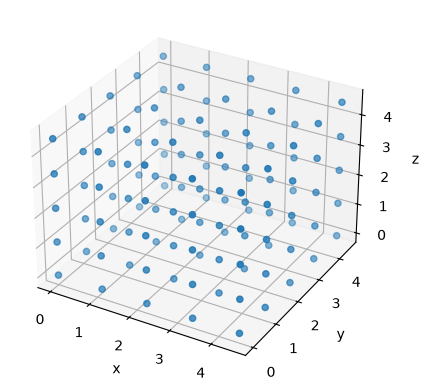

In [ ]:
# Lennard-Jones potential: V_LJ(r) = 4*eps*[(σ/r)^12 - (σ/r)^6]
# V = 0 at r = σ, minimum V = -eps at r = 2^(1/6)*σ
# At the minimum dV/dr = 0, so the force between two neighbours is zero

# Cubic lattice: particle positions are a*(i, j, k) with i, j, k = 0, ..., n-1
# n particles per side, so N = n^3 particles in total
# n = 5, N = 125
# Lattice spacing a = 2^(1/6) (minimum of the LJ potential, σ = 1)
n = 5
N = n**3
a = 2**(1/6)

# Positions: all combinations of i, j, k, multiplied by a
idx = np.arange(n)
i, j, k = np.meshgrid(idx, idx, idx, indexing='ij')
pos = a*np.column_stack([i.ravel(), j.ravel(), k.ravel()])  # shape (N, 3): x, y, z of each particle

# Plot the initial positions in 3d
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2])
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.show()

## b) Initial velocities
In the Maxwell distribution each velocity component is Gaussian with mean 0 and variance kB*T/m (Eq. 8.58 in the book).
Same as section 8.4 in the book, I use ε as the unit of energy, ε/kB as the unit of temperature and σ as the unit of length. I also set m = 1.
Then velocity is in units of sqrt(ε/m), and the variance is just T.

In [3]:
# Maxwell distribution for one velocity component: W(vx) ∝ exp(-m*vx^2 / (2*kB*T))
# This is a Gaussian with mean 0 and variance kB*T/m
# x, y and z are independent, so each component is drawn separately
# Equipartition: each component has average kinetic energy 1/2 kB*T,
# so the average kinetic energy per particle is 3/2 kB*T

# Reduced (dimensionless) units: sigma = eps = m = kB = 1
# length in sigma, energy in eps, temperature in eps/kB, velocity in sqrt(eps/m), time in sigma*sqrt(m/eps)
# In these units the variance kB*T/m is just T

# Temperature in reduced units (T = kB*T/eps)
T = 1.0

# Each component vx, vy, vz is Gaussian with mean 0 and standard deviation sqrt(T)
rng = np.random.default_rng()
vel = rng.normal(0, np.sqrt(T), size=(N, 3))

## c) Center of mass velocity
All particles have the same mass, so the center of mass velocity is the average velocity.
I subtract it from every particle so the system does not drift.

In [4]:
# Total momentum: P = sum of m*v_i, and v_cm = P / (N*m)
# The velocities are random, so P is not exactly zero for finite N (it is of order sqrt(N))
# Then the whole system would drift through space
# The LJ forces come in equal and opposite pairs (Newton's third law), so P is conserved during the simulation
# This means removing v_cm once at the start is enough

# Center of mass velocity = average of all velocities (equal masses)
v_cm = vel.mean(axis=0)
print(v_cm)

# Subtract it from every particle
vel = vel - v_cm
print(vel.mean(axis=0))  # should be ~0 now

[ 0.2347382  -0.0179655   0.05359117]
[-4.61852778e-17  8.88178420e-18 -3.10862447e-17]


Before the correction the center of mass velocity is small but not zero, because N is finite. After subtracting it, it is zero (up to rounding, ~1e-17).